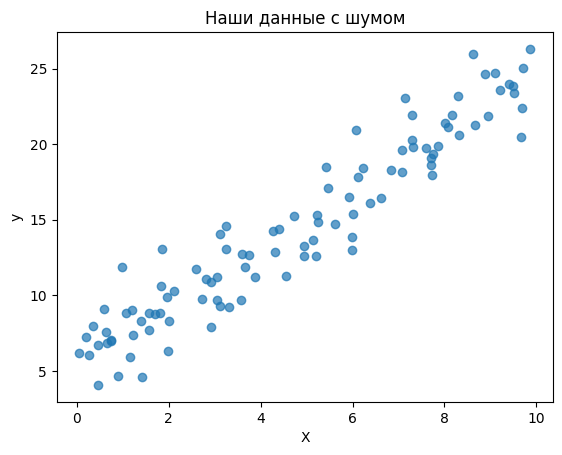

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Сделаем так, чтобы можно было воспроизвести результат
np.random.seed(42)

# Сгенерируем 100 точек
m = 100  # количество примеров

# Истинная зависимость: y = 2 * x + 5 + немного шума
X = np.random.rand(m, 1) * 10  # числа от 0 до 10
true_w = 2
true_b = 5
# Добавляем случайный гауссовский шум, чтобы данные были "как в жизни"
y = true_w * X + true_b + np.random.randn(m, 1) * 2 

# Посмотрим на данные
plt.scatter(X, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Наши данные с шумом")
plt.show()

In [ ]:
# Инициализируем веса случайными числами (очень маленькими)
w = np.random.randn(1) * 0.01

# создает одномерный массив NumPy, состоящий из одного элемента со значением 0
b = np.zeros(1)

print(f"Начальный вес (w): {w[0]:.4f}")
print(f"Начальное смещение (b): {b[0]:.4f}")

Начальный вес (w): 0.0001
Начальное смещение (b): 0.0000


In [38]:
def compute_loss(y_pred, y_true):
    """
    Считаем среднеквадратичную ошибку (MSE)
    """
    m = y_true.shape[0]
    loss = (1 / m) * np.sum((y_pred - y_true) ** 2)
    return loss

loss = (1 / m) * 

С делением мы получаем среднюю ошибку на один пример, что позволяет:
Сравнивать модели на разных наборах данных
Понимать, насколько модель ошибается "в среднем"

dw = (2 / m) * np.dot(X.T, (y_pred - y))
db = (2 / m) * np.sum(y_pred - y)


Если вы меняете функцию потерь (Loss), то меняются и формулы для градиентов (dw и db), потому что вы теперь берете производную от другой функции.

----

db — это средняя ошибка по всем объектам (без учета признаков).
dw — это та же средняя ошибка, но взвешенная по каждому признаку 
x
x. Если признак был большим, он получает большую долю ответственности за исправление ошибки! 



In [ ]:
def train_step(X, y, w, b, learning_rate=0.01):
    """
    Один шаг обучения (Forward + Backward)
    """
    m = X.shape[0]  # Количество объектов (100)

    # --- 1. Forward pass (Прямой проход) ---
    # Предсказание: перемножаем X и w, прибавляем b
    y_pred = np.dot(X, w) + b

    # --- 2. Считаем ошибку (чтобы видеть прогресс) ---
    loss = compute_loss(y_pred, y)
    
    # --- 3. Backward pass (Обратный проход) ---
    # Считаем градиенты (производные) 
    # Это и есть "цепное правило" (Chain Rule) для MSE!
    dw = (2 / m) * np.dot(X.T, (y_pred - y))
    db = (2 / m) * np.sum(y_pred - y)

    # Потому что в 2D-пространстве (где только один признак x) линия может только:
    # Поехать вверх/вниз (b).
    # Наклониться (w).

    # --- 4. Обновляем веса (Градиентный спуск) ---
    # Идем в сторону, ПРОТИВОПОЛОЖНУЮ градиенту
    w = w - learning_rate * dw
    b = b - learning_rate * db

    return w, b, loss

In [40]:
# Гиперпараметры
learning_rate = 0.0005  # Шаг спуска
epochs = 1000         # Количество итераций

# Списки для записи истории, чтобы построить график обучения
loss_history = []
w_history = []
b_history = []

print("Начинаем обучение...")
print("---")

for epoch in range(epochs):
    # Делаем один шаг обучения
    w, b, loss = train_step(X, y, w, b, learning_rate)
    
    # Сохраняем историю для графиков
    loss_history.append(loss)
    w_history.append(w[0])
    b_history.append(b[0])

    # Раз в 100 эпох печатаем прогресс
    if epoch % 100 == 0:
        print(f"Эпоха {epoch:4d} | Потеря (Loss): {loss:.4f} | w = {w.flatten()[0]:.4f} | b = {b.flatten()[0]:.4f}")

print("---")
print(f"ИТОГИ обучения:")
print(f"Истинный w = 2.0   | Наш w = {w.flatten()[0]:.4f}")
print(f"Истинный b = 5.0   | Наш b = {b.flatten()[0]:.4f}")

Начинаем обучение...
---
Эпоха    0 | Потеря (Loss): 24250.8036 | w = 0.0846 | b = 1.4401
Эпоха  100 | Потеря (Loss): 685.7107 | w = 1.2735 | b = 8.6410
Эпоха  200 | Потеря (Loss): 410.3450 | w = 1.5962 | b = 7.0083
Эпоха  300 | Потеря (Loss): 343.8229 | w = 1.7548 | b = 6.2059
Эпоха  400 | Потеря (Loss): 327.7526 | w = 1.8327 | b = 5.8114
Эпоха  500 | Потеря (Loss): 323.8704 | w = 1.8710 | b = 5.6176
Эпоха  600 | Потеря (Loss): 322.9326 | w = 1.8898 | b = 5.5223
Эпоха  700 | Потеря (Loss): 322.7060 | w = 1.8991 | b = 5.4755
Эпоха  800 | Потеря (Loss): 322.6513 | w = 1.9036 | b = 5.4524
Эпоха  900 | Потеря (Loss): 322.6380 | w = 1.9059 | b = 5.4411
---
ИТОГИ обучения:
Истинный w = 2.0   | Наш w = 1.9070
Истинный b = 5.0   | Наш b = 5.4356


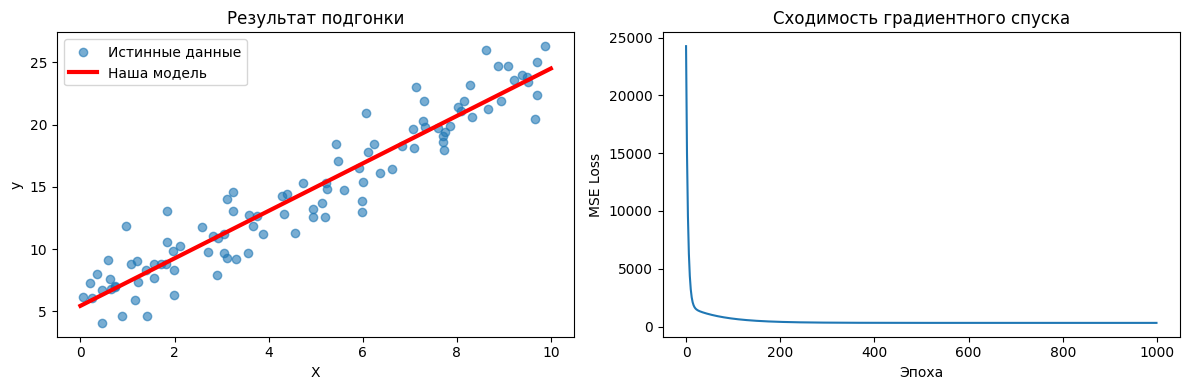

In [41]:
# График 1: Итоговая прямая на фоне данных
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.6, label='Истинные данные')
# Рисуем нашу обученную прямую
x_line = np.linspace(0, 10, 100)
y_line = w[0] * x_line + b[0]
plt.plot(x_line, y_line, color='red', linewidth=3, label='Наша модель')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Результат подгонки")

# График 2: Как уменьшалась ошибка (Loss) со временем
plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.title("Сходимость градиентного спуска")

plt.tight_layout()
plt.show()